In [1]:
import biosppy.signals as bsp

from ucsd_ecg_dataset import ECGDataset
from deep_qrs_detector import DeepQRSDetector
from deep_qrs_predictor import DeepQRSPredictor
from ecg_dataset_manager import DatasetManager

import numpy as np
import matplotlib.pyplot as plt


2023-09-21 20:27:12.965020: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-09-21 20:27:13.441493: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [24]:
from scipy.signal import resample
from ucsd_ecg_dataset import ECGDataset

ucsd_ds = ECGDataset("/media/vlermakov/data/UCSD_ECG_SOURCE_DATA")

UCSD_PROCESSED_DATASET_LOCATION = '/media/vlermakov/data/UCSDData/'
MITDB_DATASET_LOCATION = '/media/vlermakov/data/mitdb/raw/'

dm = DatasetManager(UCSD_PROCESSED_DATASET_LOCATION,'',MITDB_DATASET_LOCATION)

database = "UCSD"
start = None
stop = None

SAMPLE_STEP = 10

if(database == "MITDB"):
    testcase = '215'
    trigger_detections = None

elif(database == 'UCSD'):
    testcase = 'thorntonmr_1013202209_30_07_3'
    
    # Split testcase 
    a,b,c = testcase.split('_',2)
    detections_array = (ucsd_ds.get_trigger_detections(a,b,c) / 4.0).astype(np.int32) 



Trigger file:  /media/vlermakov/data/UCSD_ECG_SOURCE_DATA/thorntonmr/ECG3Trig_fgre_1013202209_30_07_3


In [26]:
run_parameters = {
    "DETECTION_CONFIDENCE_THRESHOLD": 30.0,
    "PEAK_COOLDOWN_THRESHOLD": 50.0
}

cnn_predictor = DeepQRSPredictor('./models/cnn_predictor.h5',run_parameters['DETECTION_CONFIDENCE_THRESHOLD'],run_parameters['PEAK_COOLDOWN_THRESHOLD'])
cnn_detector = DeepQRSDetector('./models/cnn_detector.h5')

unfiltered_ecg, annotations = dm.LoadSignalAndAnnotations(testcase, database)

qrs_peaks_predictor,_ ,p_output = cnn_predictor.detect_peaks(unfiltered_ecg,return_confidence_intervals = True)
qrs_peaks_detector,_ = cnn_detector.detect_peaks(unfiltered_ecg)

hamilton_peaks = bsp.ecg.hamilton_segmenter(unfiltered_ecg, sampling_rate=250)

cnn_detector_peaks_array = np.array(qrs_peaks_detector).astype(np.int32)
cnn_predictor_peaks_array = np.array(qrs_peaks_predictor).astype(np.int32)

hamilton_array = np.array(hamilton_peaks).squeeze()
if(annotations is None):
  annotations_array = None
else:
  annotations_array = np.array(annotations)

# Interactive preview

In [27]:
import re
import matplotlib.ticker as ticker

from ipywidgets import interact, widgets, Layout

zoom = 10
def plot_testcase(offset):
    iPlotStart = offset
    iPlotEnd = offset+zoom*cnn_predictor.SAMPLES_PER_SLICE
    plt.figure(figsize=(20,10))

    ax = plt.gca()
    ax.xaxis.set_major_locator(ticker.AutoLocator())
    ax.xaxis.set_major_formatter(lambda x, pos: f"{int(x/250.0)}s")

    plt.subplot(512)
    plt.title("CNN Predictor")

    plt.scatter(cnn_predictor_peaks_array[(cnn_predictor_peaks_array > iPlotStart) & (cnn_predictor_peaks_array < iPlotEnd)]-iPlotStart,unfiltered_ecg[cnn_predictor_peaks_array[(cnn_predictor_peaks_array > iPlotStart) & (cnn_predictor_peaks_array < iPlotEnd)]],color='red',zorder=3)
    # if(annotations_array is not None):
    #  plt.scatter(annotations_array[(annotations_array > iPlotStart) & (annotations_array < iPlotEnd)]-iPlotStart,unfiltered_ecg[annotations_array[(annotations_array > iPlotStart) & (annotations_array < iPlotEnd)]],color='green',marker="*",zorder=3)
#     if(rescaled_plot_detections is not None):
#       plt.scatter(rescaled_plot_detections[(rescaled_plot_detections > iPlotStart) & (rescaled_plot_detections < iPlotEnd)]-iPlotStart,unfiltered_ecg[rescaled_plot_detections[(rescaled_plot_detections > iPlotStart) & (rescaled_plot_detections < iPlotEnd)]],color='blue',marker=".",zorder=3)

    plt.plot(unfiltered_ecg[iPlotStart:iPlotEnd])


    for seconds_lines in range(0,iPlotEnd-iPlotStart,250):
      plt.axvline(x=seconds_lines, linestyle=':', color='gray')

    ax = plt.gca()
    ax.xaxis.set_major_locator(ticker.AutoLocator())
    ax.xaxis.set_major_formatter(lambda x, pos: f"{int(x/250.0)}s")

    plt.subplot(513)
    plt.title("Hamilton Detector")

    plt.scatter(hamilton_array[(hamilton_array > iPlotStart) & (hamilton_array < iPlotEnd)]-iPlotStart,unfiltered_ecg[hamilton_array[(hamilton_array > iPlotStart) & (hamilton_array < iPlotEnd)]],color='red',zorder=3)
    if(annotations_array is not None):
      plt.scatter(annotations_array[(annotations_array > iPlotStart) & (annotations_array < iPlotEnd)]-iPlotStart,unfiltered_ecg[annotations_array[(annotations_array > iPlotStart) & (annotations_array < iPlotEnd)]],color='green',marker="*",zorder=3)

    plt.plot(unfiltered_ecg[iPlotStart:iPlotEnd])


    for seconds_lines in range(0,iPlotEnd-iPlotStart,250):
      plt.axvline(x=seconds_lines, linestyle=':', color='gray')

    ax = plt.gca()
    ax.xaxis.set_major_locator(ticker.AutoLocator())
    ax.xaxis.set_major_formatter(lambda x, pos: f"{int(x/250.0)}s")

#     try:
    if(detections_array is not None):
        plt.subplot(514)
        plt.title("Current Trigger")


        plt.scatter(detections_array[(detections_array > iPlotStart) & (detections_array < iPlotEnd)]-iPlotStart,unfiltered_ecg[detections_array[(detections_array > iPlotStart) & (detections_array < iPlotEnd)]],color='red',zorder=3)
        if(annotations_array is not None):
            plt.scatter(annotations_array[(annotations_array > iPlotStart) & (annotations_array < iPlotEnd)]-iPlotStart,unfiltered_ecg[annotations_array[(annotations_array > iPlotStart) & (annotations_array < iPlotEnd)]],color='green',marker="*",zorder=3)
        plt.plot(unfiltered_ecg[iPlotStart:iPlotEnd])

#         plt.subplot(515)

#         plt.title("ECG3 Signal")

#         plt.scatter(detections_array[(detections_array > iPlotStart) & (detections_array < iPlotEnd)]-iPlotStart,raw_ecg3_signal[detections_array[(detections_array > iPlotStart) & (detections_array < iPlotEnd)]],color='red',zorder=3)
#         if(annotations_array is not None):
#             plt.scatter(annotations_array[(annotations_array > iPlotStart) & (annotations_array < iPlotEnd)]-iPlotStart,raw_ecg3_signal[annotations_array[(annotations_array > iPlotStart) & (annotations_array < iPlotEnd)]],color='green',marker="*",zorder=3)
#         plt.plot(unfiltered_ecg[iPlotStart:iPlotEnd])

#     except:
#       pass
    plt.show()

# create the slider widget with values from 0 to num_testcases-1
offset_slider = widgets.IntSlider(min=0, continuous_update=True,max=len(unfiltered_ecg)-int(cnn_predictor.SAMPLES_PER_SLICE*zoom)-1, step=cnn_predictor.SAMPLES_PER_SLICE, value=0,layout=Layout(width='100%'))

# use the interact function to connect the slider to the plot_testcase function
interact(plot_testcase, offset=offset_slider);

interactive(children=(IntSlider(value=0, description='offset', layout=Layout(width='100%'), max=4922, step=512…

# Inspect confidence interval predictions

In [29]:
import re
import matplotlib.ticker as ticker

from ipywidgets import interact, widgets, Layout
dataX, dataY = DeepQRSPredictor.create_windowed_dataset(cnn_predictor.SAMPLE_STEP,unfiltered_ecg,annotations)


# define a function to plot the data for a given testcase
def plot_testcase(testcase_offset):
    next_testcase_offset = testcase_offset + int(cnn_predictor.SAMPLES_PER_SLICE/cnn_predictor.SAMPLE_STEP)
    # Create the plot
    plt.figure(figsize=(20,5))
    #plt.subplot(211)
    #plt.plot(probability_array[testcase_offset*cnn_predictor.SAMPLE_STEP:testcase_offset*cnn_predictor.SAMPLE_STEP+cnn_predictor.SAMPLES_PER_SLICE + cnn_predictor.PREDICTION_WINDOW])
    plt.subplot(212)

    plt.plot(np.concatenate([dataX[testcase_offset,:,0], dataX[next_testcase_offset,:,0]]))


    print(p_output[testcase_offset,:])
    for i in range(0,2):
      predictionX = cnn_predictor.SAMPLES_PER_SLICE - cnn_predictor.DETECTION_WINDOW + cnn_predictor.PREDICTION_WINDOW*p_output[testcase_offset,i*3+1]
      predictionQ05 = cnn_predictor.SAMPLES_PER_SLICE - cnn_predictor.DETECTION_WINDOW + cnn_predictor.PREDICTION_WINDOW*p_output[testcase_offset,i*3+0]
      predictionQ95 = cnn_predictor.SAMPLES_PER_SLICE - cnn_predictor.DETECTION_WINDOW + cnn_predictor.PREDICTION_WINDOW*p_output[testcase_offset,i*3+2]
      trainingPredictionX = cnn_predictor.SAMPLES_PER_SLICE - cnn_predictor.DETECTION_WINDOW + cnn_predictor.PREDICTION_WINDOW*dataY[testcase_offset,i*3+1]
      print(f"{testcase_offset}:{predictionX} {trainingPredictionX}")

      print(f"{predictionQ05} - {predictionQ95} = {predictionQ95-predictionQ05}")

      plt.axvline(x = predictionQ05, linestyle=':', color='blue')
      plt.axvline(x = predictionQ95, linestyle=':', color='purple')
      plt.axvline(x = predictionX, linestyle=':', color='red')
      plt.axvline(x = trainingPredictionX, linestyle=':', color='green')

    plt.axvline(x = 512, linestyle='-', color='black')
    
    for p in qrs_peaks_predictor:
      p_corrected = p - testcase_offset*cnn_predictor.SAMPLE_STEP
      if p_corrected >= 0 and p_corrected < cnn_predictor.SAMPLES_PER_SLICE*2:
        #print(f"Pred d: {p_corrected} full: {p}")
        plt.axvline(x = p_corrected, linestyle='--', color='red')

    new_tick_locations = np.linspace(0,cnn_predictor.SAMPLES_PER_SLICE*2*4,4)
    #plt.xticks(np.linspace(0,SAMPLES_PER_SLICE*2*4,4))
    # Display the plot
    plt.show();


# create the slider widget with values from 0 to num_testcases-1
testcase_slider = widgets.IntSlider(min=0, continuous_update=True,max=dataX.shape[0]-int(cnn_predictor.SAMPLES_PER_SLICE/cnn_predictor.SAMPLE_STEP)-1, step=1, value=0,layout=Layout(width='100%'))

# use the interact function to connect the slider to the plot_testcase function
interact(plot_testcase, testcase_offset=testcase_slider);


interactive(children=(IntSlider(value=0, description='testcase_offset', layout=Layout(width='100%'), max=799),…

# Generate comparison figure

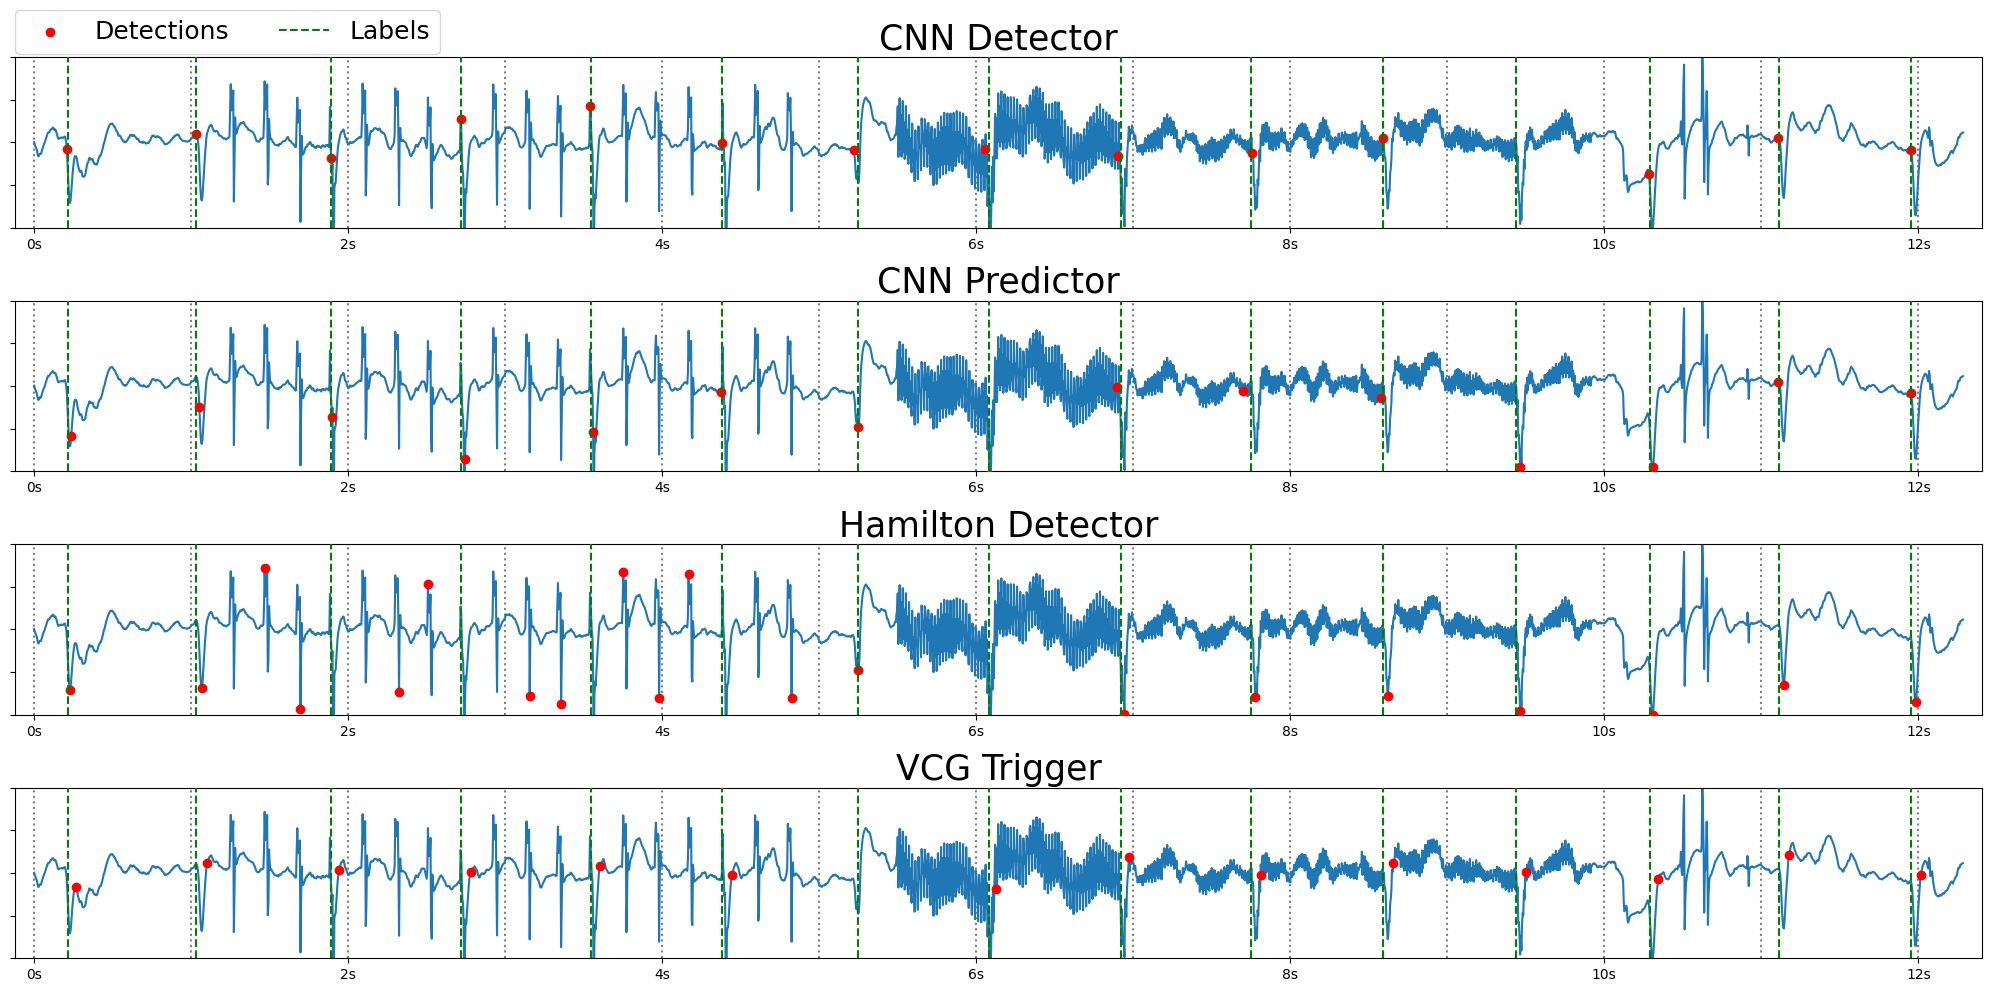

In [30]:
import re
import matplotlib.ticker as ticker
#import ecg_plot

iPlotStart = 2000
iPlotEnd = iPlotStart+6*cnn_predictor.SAMPLES_PER_SLICE
fig = plt.figure(figsize=(20,10))

# plt.subplot(211)
# plt.title("Probability (Debugging)")
# plt.plot(probability_array[iPlotStart:iPlotEnd])
# plt.scatter(peaks_array[(peaks_array > iPlotStart) & (peaks_array < iPlotEnd)]-iPlotStart,probability_array[peaks_array[(peaks_array > iPlotStart) & (peaks_array < iPlotEnd)]],color='red')
# if(annotations_array is not None):
#   plt.scatter(annotations_array[(annotations_array > iPlotStart) & (annotations_array < iPlotEnd)]-iPlotStart,probability_array[annotations_array[(annotations_array > iPlotStart) & (annotations_array < iPlotEnd)]],color='green',marker="*")
plt.subplot(411)
plt.title("CNN Detector", fontsize = 25)

for seconds_lines in range(0,iPlotEnd-iPlotStart,250):
  plt.axvline(x=seconds_lines, linestyle=':', color='gray')

plt.scatter(cnn_detector_peaks_array[(cnn_detector_peaks_array > iPlotStart) & (cnn_detector_peaks_array < iPlotEnd)]-iPlotStart,unfiltered_ecg[cnn_detector_peaks_array[(cnn_detector_peaks_array > iPlotStart) & (cnn_detector_peaks_array < iPlotEnd)]],color='red',label='Detections',zorder=3)
if(annotations_array is not None):
  for ind,label in enumerate(annotations_array[(annotations_array > iPlotStart) & (annotations_array < iPlotEnd)]):
    if(ind == 0):
      plt.axvline(x=(label - iPlotStart), linestyle='--', color='green',label='Labels',zorder=3)
    else:
      plt.axvline(x=(label - iPlotStart), linestyle='--', color='green',zorder=3)


plt.plot(unfiltered_ecg[iPlotStart:iPlotEnd])
plt.margins(0.01)
ax = plt.gca()
ax.set_ylim([-20000, 20000])
ax.xaxis.set_major_locator(ticker.AutoLocator())
ax.xaxis.set_major_formatter(lambda x, pos: f"{int(x/250.0)}s")
ax.set_yticklabels([])

plt.legend(bbox_to_anchor=(0, 1.02), loc="lower left",
                borderaxespad=0, ncol=3,fontsize = 18)
plt.subplot(412)
plt.title("CNN Predictor", fontsize = 25)

for seconds_lines in range(0,iPlotEnd-iPlotStart,250):
  plt.axvline(x=seconds_lines, linestyle=':', color='gray')

plt.scatter(cnn_predictor_peaks_array[(cnn_predictor_peaks_array > iPlotStart) & (cnn_predictor_peaks_array < iPlotEnd)]-iPlotStart,unfiltered_ecg[cnn_predictor_peaks_array[(cnn_predictor_peaks_array > iPlotStart) & (cnn_predictor_peaks_array < iPlotEnd)]],color='red',label='Detections',zorder=3)
if(annotations_array is not None):
  for ind,label in enumerate(annotations_array[(annotations_array > iPlotStart) & (annotations_array < iPlotEnd)]):
    if(ind == 0):
      plt.axvline(x=(label - iPlotStart), linestyle='--', color='green',label='Labels',zorder=3)
    else:
      plt.axvline(x=(label - iPlotStart), linestyle='--', color='green',zorder=3)


plt.plot(unfiltered_ecg[iPlotStart:iPlotEnd])
plt.margins(0.01)
ax = plt.gca()
ax.set_ylim([-20000, 20000])
ax.xaxis.set_major_locator(ticker.AutoLocator())
ax.xaxis.set_major_formatter(lambda x, pos: f"{int(x/250.0)}s")
ax.set_yticklabels([])


plt.subplot(413)
plt.title("Hamilton Detector", fontsize = 25)
for seconds_lines in range(0,iPlotEnd-iPlotStart,250):
  plt.axvline(x=seconds_lines, linestyle=':', color='gray')

plt.scatter(hamilton_array[(hamilton_array > iPlotStart) & (hamilton_array < iPlotEnd)]-iPlotStart,unfiltered_ecg[hamilton_array[(hamilton_array > iPlotStart) & (hamilton_array < iPlotEnd)]],color='red',zorder=3)
if(annotations_array is not None):
  for label in annotations_array[(annotations_array > iPlotStart) & (annotations_array < iPlotEnd)]:
    plt.axvline(x=(label - iPlotStart), linestyle='--', color='green',zorder=3)
plt.plot(unfiltered_ecg[iPlotStart:iPlotEnd])
plt.margins(0.01)
ax = plt.gca()
ax.set_ylim([-20000, 20000])
ax.set_yticklabels([])
ax.xaxis.set_major_locator(ticker.AutoLocator())
ax.xaxis.set_major_formatter(lambda x, pos: f"{int(x/250.0)}s")
plt.subplot(414)
plt.title("VCG Trigger", fontsize = 25)
for seconds_lines in range(0,iPlotEnd-iPlotStart,250):
  plt.axvline(x=seconds_lines, linestyle=':', color='gray')
plt.scatter(detections_array[(detections_array > iPlotStart) & (detections_array < iPlotEnd)]-iPlotStart,unfiltered_ecg[detections_array[(detections_array > iPlotStart) & (detections_array < iPlotEnd)]],color='red',zorder=3)
if(annotations_array is not None):
  for label in annotations_array[(annotations_array > iPlotStart) & (annotations_array < iPlotEnd)]:
    plt.axvline(x=(label - iPlotStart), linestyle='--', color='green',zorder=3)
plt.plot(unfiltered_ecg[iPlotStart:iPlotEnd])
plt.margins(0.01)
ax = plt.gca()
ax.set_ylim([-20000, 20000])

ax.xaxis.set_major_locator(ticker.AutoLocator())
ax.xaxis.set_major_formatter(lambda x, pos: f"{int(x/250.0)}s")
ax.set_yticklabels([])

fig.tight_layout(pad=1.0)
plt.show()
